In [9]:
from google.colab import files

uploaded = files.upload()

Saving airline_arrivals.csv to airline_arrivals (1).csv


Once you have uploaded your file, you can read it into a pandas DataFrame. If you uploaded a file named `your_file_name.csv`, you can use the following code. Please replace `your_file_name.csv` with the actual name of your uploaded file.

In [10]:
import pandas as pd

df = pd.read_csv('airline_arrivals.csv')
print(df)

   airline   status  los_angeles  phoenix  san_diego  san_francisco  seattle
0   ALASKA  on time          497      221        212            503     1841
1   ALASKA  delayed           62       12         20            102      305
2  AM WEST  on time          694     4840        383            320      201
3  AM WEST  delayed          117      415         65            129       61


I uploaded my csv file on Google Colab and ensured the file can be read

In [19]:
alaska = df[df['airline'] == 'ALASKA']
amwest = df[df['airline'] == 'AM WEST']

print("Delay Rate")

cities = ['los_angeles', 'phoenix', 'san_diego', 'san_francisco', 'seattle']

for city in cities:
    ak_delayed = alaska[alaska['status'] == 'delayed'][city].values[0]
    ak_total = alaska[city].sum()
    ak_rate = round(ak_delayed / ak_total * 100, 2)

    aw_delayed = amwest[amwest['status'] == 'delayed'][city].values[0]
    aw_total = amwest[city].sum()
    aw_rate = round(aw_delayed / aw_total * 100, 2)

    print(f"{city}: ALASKA = {ak_rate}%  |  AM WEST = {aw_rate}%")


Delay Rate
los_angeles: ALASKA = 11.09%  |  AM WEST = 14.43%
phoenix: ALASKA = 5.15%  |  AM WEST = 7.9%
san_diego: ALASKA = 8.62%  |  AM WEST = 14.51%
san_francisco: ALASKA = 16.86%  |  AM WEST = 28.73%
seattle: ALASKA = 14.21%  |  AM WEST = 23.28%


Find "delayed" rows, grab the number, store it
Add up all flights
Calculate the delay percentage round to 2 decimal places

In [13]:
ak_total_delayed = alaska[alaska['status'] == 'delayed'][cities].sum().sum()
ak_total_flights = alaska[cities].sum().sum()
print(f"ALASKA overall delay rate: {round(ak_total_delayed / ak_total_flights * 100, 2)}%")

aw_total_delayed = amwest[amwest['status'] == 'delayed'][cities].sum().sum()
aw_total_flights = amwest[cities].sum().sum()
print(f"AM WEST overall delay rate: {round(aw_total_delayed / aw_total_flights * 100, 2)}%")

ALASKA overall delay rate: 13.27%
AM WEST overall delay rate: 10.89%


overall delay percentage for each airline across all cities combined.
First sum() adds down each column. Second sum() adds those column totals together.

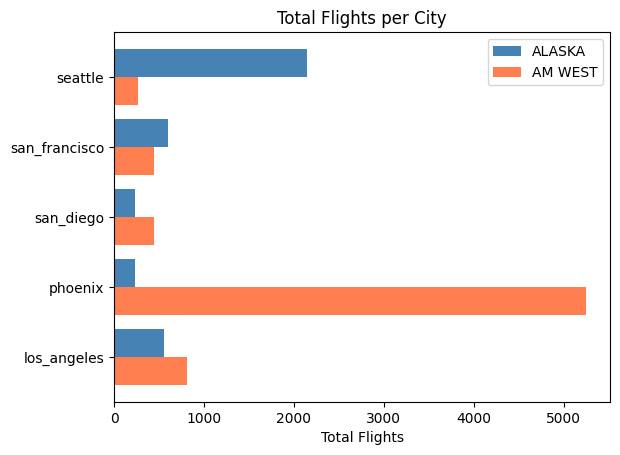

In [15]:
import matplotlib.pyplot as plt

ak_totals = [alaska[city].sum() for city in cities]
aw_totals = [amwest[city].sum() for city in cities]

x = range(len(cities))
plt.barh([i + 0.2 for i in x], ak_totals, height=0.4, label='ALASKA', color='steelblue')
plt.barh([i - 0.2 for i in x], aw_totals, height=0.4, label='AM WEST', color='coral')
plt.yticks(list(x), cities)
plt.xlabel('Total Flights')
plt.title('Total Flights per City')
plt.legend()
plt.show()

Add up all flights, store in list.
plt.barh draws horizontal bars for airlines. The + 0.2 moves bars slightly up no overlap.

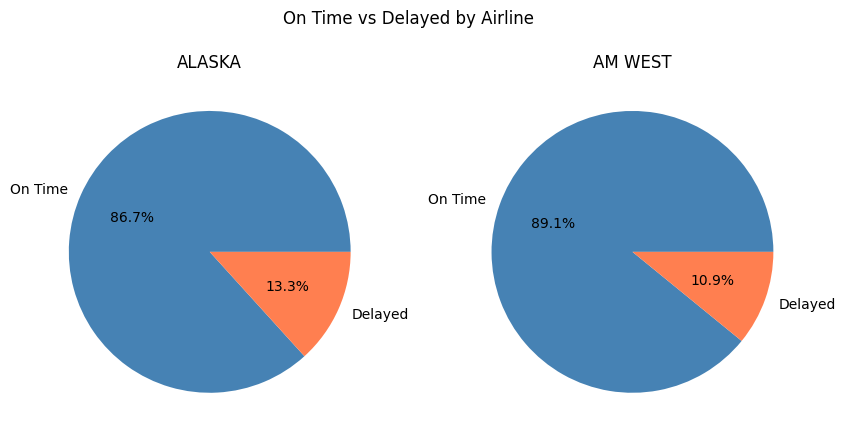

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ak_delayed = alaska[alaska['status'] == 'delayed'][cities].sum().sum()
ak_ontime = alaska[alaska['status'] == 'on time'][cities].sum().sum()
axes[0].pie([ak_ontime, ak_delayed], labels=['On Time', 'Delayed'], autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[0].set_title('ALASKA')

aw_delayed = amwest[amwest['status'] == 'delayed'][cities].sum().sum()
aw_ontime = amwest[amwest['status'] == 'on time'][cities].sum().sum()
axes[1].pie([aw_ontime, aw_delayed], labels=['On Time', 'Delayed'], autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[1].set_title('AM WEST')

plt.suptitle('On Time vs Delayed by Airline')
plt.show()

Set up area with 2 charts. Add up delayed and on time for both airlines. use pie function to create pie graph with information.